### ARMA and ARIMA Modeling and Forecasting

#### Estimation Methods

**Innovation Algorithm** - compute one step ahead linear predictors recursively.

### Modelling Practice

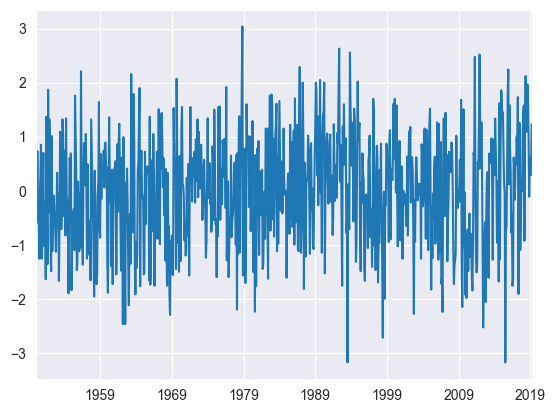

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
from statsmodels.graphics.tsaplots import plot_pacf, plot_acf
from statsmodels.tsa.arima_model import ARMA

from PythonTsa.LjungBoxtest import plot_LB_pvalue
from PythonTsa.datadir import getdtapath

dtapath = getdtapath()
nao = pd.read_csv(dtapath + 'nao.csv', header=0)
timeindex = pd.date_range('1950-01', periods=len(nao), freq='ME')
nao.index=timeindex
naots=nao['index']

naots.plot()
plt.show()

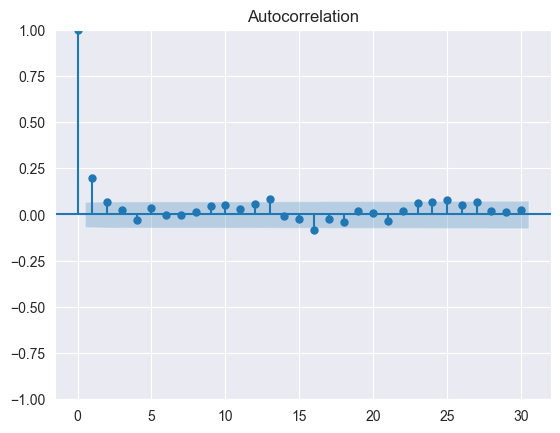

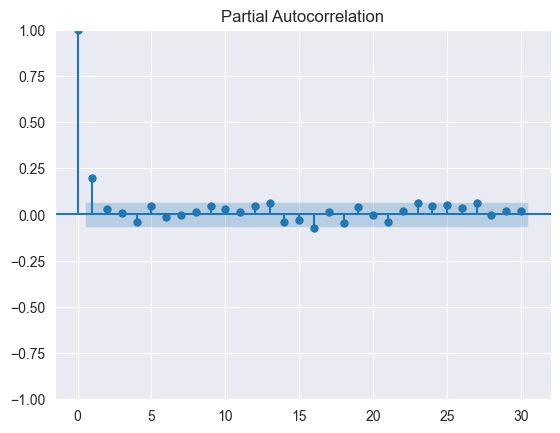

In [4]:
plot_acf(naots)
plt.show()
plot_pacf(naots)
plt.show()

**Building first AR(1) model**

In [9]:
from statsmodels.tsa.arima.model import ARIMA


ar1 = ARIMA(naots, order=(1, 0, 0)).fit()
print(ar1.summary())

                               SARIMAX Results                                
Dep. Variable:                  index   No. Observations:                  831
Model:                 ARIMA(1, 0, 0)   Log Likelihood               -1176.007
Date:                Tue, 31 Mar 2026   AIC                           2358.013
Time:                        12:22:03   BIC                           2372.181
Sample:                    01-31-1950   HQIC                          2363.446
                         - 03-31-2019                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0040      0.043      0.092      0.927      -0.081       0.089
ar.L1          0.1996      0.033      6.041      0.000       0.135       0.264
sigma2         0.9924      0.054     18.443      0.0

<Axes: >

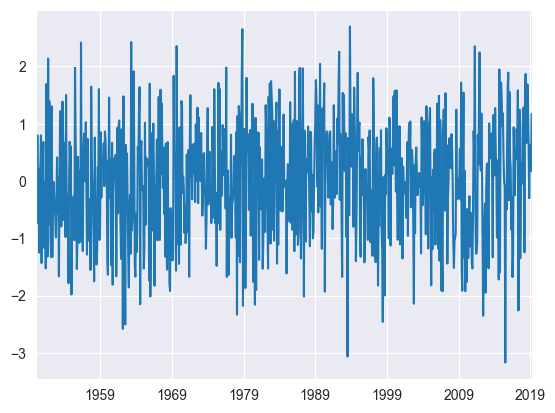

In [11]:
resid1 = ar1.resid
resid1.plot()

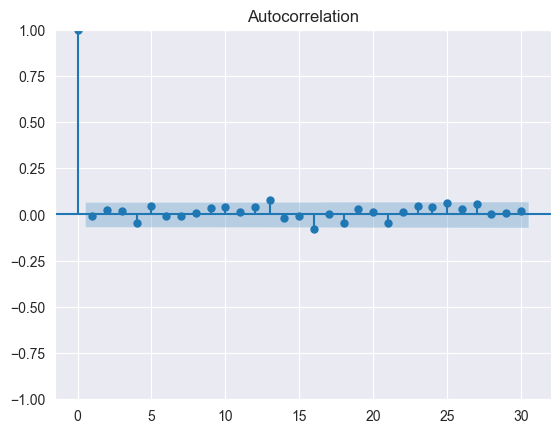

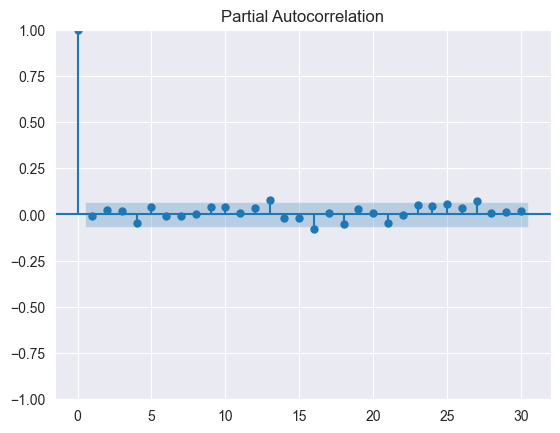

In [13]:
plot_acf(resid1)
plt.show()
plot_pacf(resid1)
plt.show()

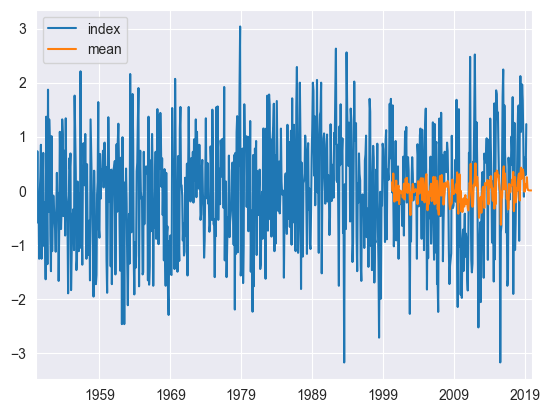

In [26]:
pred = ar1.get_prediction(start='2000-04', end='2019-12')
pred_df = pred.summary_frame()

pred_df_mean = pred_df['mean']

naots.plot()
pred_df_mean.plot()
plt.legend()
plt.show()
